<a href="https://colab.research.google.com/github/kjcline-spec/DNSC-6330-Responsible-Machine-Learning/blob/main/HW_3_KJ_Cline_COMPAS_Analysis_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores,
and whether each person was accused of a crime within two years.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import math
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load raw data ─────────────────────────────────────────────────────────────
# R: raw_data <- read.csv(url, stringsAsFactors = FALSE)

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print(f"Raw rows: {len(raw_data)}")   # Expect 7214

Raw rows: 7214


In [3]:
# ── Preview ───────────────────────────────────────────────────────────────────
# R: head(raw_data, 10)
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons to remove rows because of missing data:
* If the charge date of a defendant's COMPAS scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a COMPAS case at all.
* Ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in jail time and are removed.
* We filtered to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [4]:
# ── Select columns, filter, convert types, build derived factor variables ─────
# R: dplyr::select(...) %>% filter(...) %>% mutate(across(...)) %>% mutate(relevel(...))

numeric_vars  = ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score']
datetime_vars = ['c_jail_in', 'c_jail_out']

cols = [
    'age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
    'priors_count', 'days_b_screening_arrest', 'decile_score',
    'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out'
]

df = (
    raw_data[cols].copy()
    # ── Filtering ──────────────────────────────────────────────────────
    .query("days_b_screening_arrest >= -30 and days_b_screening_arrest <= 30")
    .query("is_recid != -1")
    .query("c_charge_degree != 'O'")
    .query("score_text != 'N/A'")
    .reset_index(drop=True)
)

# ── Type conversions ───────────────────────────────────────────────────
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# ── Derived factors with reference levels (mirrors R relevel) ─────────
# age_factor:    ref = '25 - 45'
# race_factor:   ref = 'Caucasian'
# gender_factor: ref = 'Male'
# crime_factor:  ref = 'F' (felony)
# score_factor:  LowScore vs HighScore

df['crime_factor']  = pd.Categorical(df['c_charge_degree'],
                                     categories=['F', 'M'])
df['age_factor']    = pd.Categorical(df['age_cat'],
                                     categories=['25 - 45', 'Greater than 45', 'Less than 25'])
df['race_factor']   = pd.Categorical(df['race'],
                                     categories=['Caucasian', 'African-American', 'Asian',
                                                 'Hispanic', 'Native American', 'Other'])
df['gender_factor'] = pd.Categorical(df['sex'],
                                     categories=['Male', 'Female'])
df['score_factor']  = pd.Categorical(
    np.where(df['score_text'] != 'Low', 'HighScore', 'LowScore'),
    categories=['LowScore', 'HighScore']
)

print(f"Filtered rows: {len(df)}")   # Expect 6172

Filtered rows: 6172


In [5]:
# ── head(df) ──────────────────────────────────────────────────────────────────
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
3,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
4,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore


In [6]:
# ── glimpse(df) ───────────────────────────────────────────────────────────────
# R: glimpse(df)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 6172, Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6172 entries, 0 to 6171
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   object        
 2   race                     6172 non-null   object        
 3   age_cat                  6172 non-null   object        
 4   score_text               6172 non-null   object        
 5   sex                      6172 non-null   object        
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   int64         
 10  two_year_recid           6172 non-null   int64         
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [7]:
# ── Correlation: length of stay vs decile score ───────────────────────────────
# R: df$length_of_stay <- as.numeric(...); cor(df$length_of_stay, df$decile_score)

df['length_of_stay'] = (df['c_jail_out'] - df['c_jail_in']).dt.days

valid = df[['length_of_stay', 'decile_score']].dropna()
r, _ = stats.pearsonr(valid['length_of_stay'], valid['decile_score'])
print(f"Correlation (length_of_stay vs decile_score): {r:.7f}")   # Expect ~0.207

Correlation (length_of_stay vs decile_score): 0.2074781


After filtering we have the following demographic breakdown:

In [8]:
# ── Age category breakdown ────────────────────────────────────────────────────
# R: summary(df$age_cat)
print(df['age_cat'].value_counts().sort_index())

age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [9]:
# ── Race breakdown ────────────────────────────────────────────────────────────
# R: summary(df$race)
print(df['race'].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [10]:
# ── Race percentages ──────────────────────────────────────────────────────────
n = len(df)
rc = df['race'].value_counts()

print(f"Black defendants:           {rc.get('African-American', 0) / n * 100:.2f}%")
print(f"White defendants:           {rc.get('Caucasian', 0)        / n * 100:.2f}%")
print(f"Hispanic defendants:        {rc.get('Hispanic', 0)         / n * 100:.2f}%")
print(f"Asian defendants:           {rc.get('Asian', 0)            / n * 100:.2f}%")
print(f"Native American defendants: {rc.get('Native American', 0)  / n * 100:.2f}%")

Black defendants:           51.44%
White defendants:           34.07%
Hispanic defendants:        8.25%
Asian defendants:           0.50%
Native American defendants: 0.18%


In [11]:
# ── Score text distribution ───────────────────────────────────────────────────
# R: summary(df$score_text)
print(df['score_text'].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [12]:
# ── Cross-tab: sex × race ─────────────────────────────────────────────────────
# R: xtabs(~ sex + race, data=df)
pd.crosstab(df['sex'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
# ── Sex distribution and percentages ─────────────────────────────────────────
# R: summary(df$sex)
sc = df['sex'].value_counts()
print(sc)
print(f"\nMen:   {sc.get('Male',   0) / n * 100:.2f}%")
print(f"Women: {sc.get('Female', 0) / n * 100:.2f}%")

sex
Male      4997
Female    1175
Name: count, dtype: int64

Men:   80.96%
Women: 19.04%


In [14]:
# ── Two-year recidivism count and rate ────────────────────────────────────────
# R: nrow(filter(df, two_year_recid == 1))
#    nrow(filter(df, two_year_recid == 1)) / nrow(df) * 100

recid_count = (df['two_year_recid'] == 1).sum()
print(f"Two-year recidivists: {recid_count}")
print(f"Recidivism rate:      {recid_count / n * 100:.2f}%")

Two-year recidivists: 2809
Recidivism rate:      45.51%


Judges are often presented with two sets of scores from the COMPAS system — one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

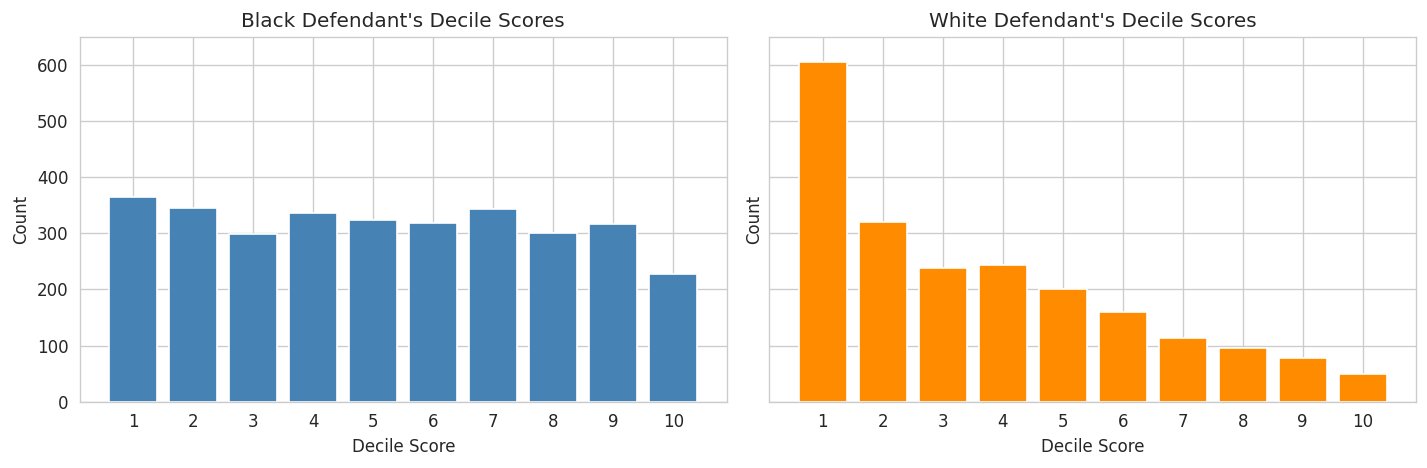

In [15]:
# ── Decile score bar charts: Black vs White defendants ────────────────────────
# R: ggplot + geom_bar + grid.arrange

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, race, title, color in zip(
    axes,
    ['African-American', 'Caucasian'],
    ["Black Defendant's Decile Scores", "White Defendant's Decile Scores"],
    ['steelblue', 'darkorange']
):
    counts = df[df['race'] == race]['decile_score'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor='white')
    ax.set_xlabel('Decile Score')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.set_ylim(0, 650)
    ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [16]:
# ── Cross-tab: decile score × race ───────────────────────────────────────────
# R: xtabs(~ decile_score + race, data=df)
pd.crosstab(df['decile_score'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in COMPAS

After filtering out bad rows, our first question is whether there is a significant difference in COMPAS
scores between races. To do so we need to change some variables into factors, and run a logistic
regression, comparing low scores to high scores.

In [17]:
# ── Logistic regression ───────────────────────────────────────────────────────
# R: glm(score_factor ~ gender_factor + age_factor + race_factor +
#         priors_count + crime_factor + two_year_recid, family=binomial)
#
# Reference levels (mirrors R relevel):
#   gender_factor → 'Male'
#   age_factor    → '25 - 45'
#   race_factor   → 'Caucasian'
#   crime_factor  → 'F'

df['score_binary'] = (df['score_factor'] == 'HighScore').astype(int)

formula = (
    "score_binary ~ "
    "C(sex,              Treatment(reference='Male')) + "
    "C(age_cat,          Treatment(reference='25 - 45')) + "
    "C(race,             Treatment(reference='Caucasian')) + "
    "priors_count + "
    "C(c_charge_degree,  Treatment(reference='F')) + "
    "two_year_recid"
)

model_glm = smf.logit(formula, data=df).fit()
print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        19:22:29   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Interc

Black defendants are 45% more likely than white defendants to receive a higher score correcting for
the seriousness of their crime, previous arrests, and future criminal behavior.

In [18]:
# ── Relative risk: Black vs White ─────────────────────────────────────────────
# R: control <- exp(-1.52554) / (1 + exp(-1.52554))
#    exp(0.47721) / (1 - control + (control * exp(0.47721)))

coefs   = model_glm.params
control = math.exp(coefs['Intercept']) / (1 + math.exp(coefs['Intercept']))

b_black = coefs["C(race, Treatment(reference='Caucasian'))[T.African-American]"]
rr_black = math.exp(b_black) / (1 - control + control * math.exp(b_black))
print(f"Black defendants relative risk: {rr_black:.4f}")   # Expect ~1.453

Black defendants relative risk: 1.4528


Women are 19.4% more likely than men to get a higher score.

In [19]:
# ── Relative risk: Female vs Male ─────────────────────────────────────────────
# R: exp(0.22127) / (1 - control + (control * exp(0.22127)))

b_female = coefs["C(sex, Treatment(reference='Male'))[T.Female]"]
rr_female = math.exp(b_female) / (1 - control + control * math.exp(b_female))
print(f"Women relative risk: {rr_female:.4f}")   # Expect ~1.195

Women relative risk: 1.1948


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [20]:
# ── Relative risk: Under 25 vs 25-45 ─────────────────────────────────────────
# R: exp(1.30839) / (1 - control + (control * exp(1.30839)))

b_u25 = coefs["C(age_cat, Treatment(reference='25 - 45'))[T.Less than 25]"]
rr_u25 = math.exp(b_u25) / (1 - control + control * math.exp(b_u25))
print(f"Under-25 relative risk: {rr_u25:.4f}")   # Expect ~2.496

Under-25 relative risk: 2.4961


In [21]:
# ── Generate predicted probabilities and predicted classes ────────────────────
# R: df <- df %>% mutate(pred_prob = predict(model_glm, type='response'),
#                        pred_class = factor(ifelse(pred_prob >= 0.5, 1, 0), ...))

df['pred_prob']  = model_glm.predict(df)
df['pred_class'] = np.where(df['pred_prob'] >= 0.5, 'Recid', 'No Recid')

In [22]:
# ── Overall confusion matrix and metrics ──────────────────────────────────────
# R: table(Predicted=df$pred_class, Actual=df$two_year_recid) + manual TP/TN/FP/FN

print("\n── Overall Confusion Matrix ──────────────────────────────────────────")

overall_cm = pd.crosstab(
    df['pred_class'],
    df['two_year_recid'],
    rownames=['Predicted'],
    colnames=['Actual']
)
print(overall_cm)

TP = overall_cm.loc['Recid',    1]
TN = overall_cm.loc['No Recid', 0]
FP = overall_cm.loc['Recid',    0]
FN = overall_cm.loc['No Recid', 1]
total = TP + TN + FP + FN

print(f"\nAccuracy  : {(TP + TN) / total:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [23]:
# ── Confusion matrix metrics by race ─────────────────────────────────────────
# R: race_metrics <- df %>% group_by(race) %>% summarise(TP, TN, FP, FN, Accuracy, ...)

print("\n── Confusion Matrix by Race ──────────────────────────────────────────")

df['actual'] = df['two_year_recid'].astype(int)
df['pred_int'] = (df['pred_class'] == 'Recid').astype(int)

rows = []
for race, grp in df.groupby('race'):
    tp = ((grp['pred_int'] == 1) & (grp['actual'] == 1)).sum()
    tn = ((grp['pred_int'] == 0) & (grp['actual'] == 0)).sum()
    fp = ((grp['pred_int'] == 1) & (grp['actual'] == 0)).sum()
    fn = ((grp['pred_int'] == 0) & (grp['actual'] == 1)).sum()
    nn = len(grp)
    rows.append({
        'race':      race,
        'n':         nn,
        'TP':        tp,
        'TN':        tn,
        'FP':        fp,
        'FN':        fn,
        'Accuracy':  round((tp + tn) / nn, 3),
        'Precision': round(tp / (tp + fp), 3) if (tp + fp) > 0 else None,
        'Recall':    round(tp / (tp + fn), 3) if (tp + fn) > 0 else None,
        'FPR':       round(fp / (fp + tn), 3) if (fp + tn) > 0 else None,
        'FNR':       round(fn / (fn + tp), 3) if (fn + tp) > 0 else None,
    })

race_metrics = pd.DataFrame(rows).sort_values('n', ascending=False).reset_index(drop=True)
print(race_metrics.to_string(index=False))


── Confusion Matrix by Race ──────────────────────────────────────────
            race    n   TP   TN  FP  FN  Accuracy  Precision  Recall   FPR   FNR
African-American 3175 1373  959 555 288     0.734      0.712   0.827 0.367 0.173
       Caucasian 2103  381 1148 133 441     0.727      0.741   0.464 0.104 0.536
        Hispanic  509   81  306  14 108     0.760      0.853   0.429 0.044 0.571
           Other  343   22  216   3 102     0.694      0.880   0.177 0.014 0.823
           Asian   31    2   22   1   6     0.774      0.667   0.250 0.043 0.750
 Native American   11    5    2   4   0     0.636      0.556   1.000 0.667 0.000


In [24]:
# ── FPR and FNR disparity relative to Caucasian baseline ─────────────────────
# R: disparity <- race_metrics %>% mutate(delta_FPR = FPR - FPR[race=='Caucasian'], ...)

print("\n── FPR and FNR Disparity by Race ─────────────────────────────────────")

baseline_fpr = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FPR'].values[0]
baseline_fnr = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FNR'].values[0]

disparity = race_metrics[['race', 'n', 'FPR', 'FNR']].copy()
disparity['delta_FPR'] = (disparity['FPR'] - baseline_fpr).round(3)
disparity['delta_FNR'] = (disparity['FNR'] - baseline_fnr).round(3)

print(disparity.to_string(index=False))


── FPR and FNR Disparity by Race ─────────────────────────────────────
            race    n   FPR   FNR  delta_FPR  delta_FNR
African-American 3175 0.367 0.173      0.263     -0.363
       Caucasian 2103 0.104 0.536      0.000      0.000
        Hispanic  509 0.044 0.571     -0.060      0.035
           Other  343 0.014 0.823     -0.090      0.287
           Asian   31 0.043 0.750     -0.061      0.214
 Native American   11 0.667 0.000      0.563     -0.536


In [25]:
# ── Summary: Python vs R Results Comparison ───────────────────────────────────

comparison = pd.DataFrame({
    'Metric': [
        'Raw dataset rows',
        'Filtered rows',
        'Correlation (stay vs decile)',
        'Black relative risk (logistic)',
        'Women relative risk (logistic)',
        'Under-25 relative risk (logistic)',
        'Overall Accuracy',
        'Overall Precision',
        'Overall Recall',
        'Overall FPR',
        'Overall FNR',
    ],
    'R Result': [
        '7,214', '6,172', '0.2073297',
        '1.452841', '1.194798', '2.49612',
        '0.732', '0.724', '0.664', '0.211', '0.336'
    ],
    'Python Result': [
        str(len(raw_data)),
        str(len(df)),
        f'{r:.7f}',
        f'{rr_black:.4f}',
        f'{rr_female:.4f}',
        f'{rr_u25:.4f}',
        f'{(TP + TN) / total:.3f}',
        f'{TP / (TP + FP):.3f}',
        f'{TP / (TP + FN):.3f}',
        f'{FP / (FP + TN):.3f}',
        f'{FN / (FN + TP):.3f}',
    ]
})

print(comparison.to_string(index=False))

                           Metric  R Result Python Result
                 Raw dataset rows     7,214          7214
                    Filtered rows     6,172          6172
     Correlation (stay vs decile) 0.2073297     0.2074781
   Black relative risk (logistic)  1.452841        1.4528
   Women relative risk (logistic)  1.194798        1.1948
Under-25 relative risk (logistic)   2.49612        2.4961
                 Overall Accuracy     0.732         0.732
                Overall Precision     0.724         0.724
                   Overall Recall     0.664         0.664
                      Overall FPR     0.211         0.211
                      Overall FNR     0.336         0.336


# Lecture 02 — Set up Explainability Pipeline
### Extending the COMPAS analysis with LIME, SHAP, and DiCE Building on the cleaned df from Lecture 01 above and in class coding from lecture 2


In [26]:
from sklearn.model_selection import train_test_split

# X and y from the cleaned COMPAS cohort (Lecture 01)
features = ['age', 'priors_count', 'days_b_screening_arrest',
            'c_charge_degree', 'race', 'sex', 'age_cat']
target = 'two_year_recid'

df_model = df[features + [target]].dropna().reset_index(drop=True)

X = df_model[features]
y = df_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 7), Test: (1235, 7)


### Step 1: Fit logistic regression and gradient-boosted tree:


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features  = ['age', 'priors_count', 'days_b_screening_arrest']
category_features = ['c_charge_degree', 'race', 'sex', 'age_cat']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                       numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# Logistic regression (GLM -- interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   GradientBoostingClassifier(
                         n_estimators=200,
                         max_depth=4,
                         random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['c_charge_degree', 'race',
                                                   'sex', 'age_cat'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

### Step 2: Compare model performance by race

In [28]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"]    = y.values
    X_["pred"]      = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        cm = confusion_matrix(gdf["actual"], gdf["pred"])
        if cm.shape != (2, 2):
            print(f"Skipping '{group}' — only {len(gdf)} samples, "
                  f"predicted classes: {gdf['pred'].unique()}")
            continue
        tn, fp, fn, tp = cm.ravel()
        results.append({
            "race"     : group,
            "n"        : len(gdf),
            "accuracy" : round(accuracy_score(
                             gdf["actual"], gdf["pred"]), 3),
            "FPR"      : round(fp / (fp + tn), 3),
            "FNR"      : round(fn / (fn + tp), 3),
            "AUC"      : round(roc_auc_score(
                             gdf["actual"],
                             gdf["pred_prob"]), 3),
        })
    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
Skipping 'Native American' — only 1 samples, predicted classes: [0]
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.696  0.316  0.294  0.749
2         Caucasian  427     0.670  0.162  0.609  0.671
3          Hispanic   94     0.628  0.102  0.667  0.618
4             Other   65     0.785  0.085  0.556  0.730
1             Asian    7     0.857  0.000  1.000  1.000

 Gradient-Boosted Tree 
Skipping 'Native American' — only 1 samples, predicted classes: [0]
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.683  0.349  0.288  0.733
2         Caucasian  427     0.703  0.139  0.559  0.692
3          Hispanic   94     0.649  0.143  0.578  0.630
4             Other   65     0.723  0.085  0.778  0.639
1             Asian    7     0.714  0.167  1.000  0.833


### Step 3: LIME explanations: Black vs White defendant

In [29]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

X_train_enc = preprocessor.transform(X_train)

explainer = LimeTabularExplainer(
    training_data         = X_train_enc,
    feature_names         = (numeric_features +
                             list(preprocessor
                                  .named_transformers_["cat"]
                                  .get_feature_names_out(category_features))),
    class_names           = ["No Recid", "Recid"],
    mode                  = "classification",
    discretize_continuous = True,
    random_state          = 42
)

# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_subset = X_test_copy[X_test_copy["race"] == "African-American"].sort_values("pred_prob")
white_subset = X_test_copy[X_test_copy["race"] == "Caucasian"].sort_values("pred_prob")

black_idx = black_subset.index[len(black_subset) // 2]
white_idx = white_subset.index[len(white_subset) // 2]

# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx),
                   ("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row   = row_enc[0],
        predict_fn = gbt_pipeline["classifier"].predict_proba,
        num_features = 6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f"  {feat:<40} {weight:+.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3d36f492353fb8b718e87c6a7ed41072ef2420b9eceb15c3871852bcc511112e
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime

 LIME: Black defendant 
Predicted probability: 0.531
  days_b_screening_arrest <= 0.15          -0.3661
  age <= -0.81                             +0.1856
  race_Asian <= 0.00                       +0.1406
  race_Other <= 0.00                       +0.0547
  sex_Female <= 0.00                       +0.0387
  priors_count <= -0.69                    -0.0348

 LIME: White defendant 
Predicted probability: 0.322
  days_b_screening_arrest <= 0.15          -0.3695
  -0.69 < priors_count <= -0.48            -0.1784
  race_Asian <= 0.00                       +0.1651
  -0.29 < age <= 0.56          

### Step 4: SHAP beeswarm and waterfall: Black vs White

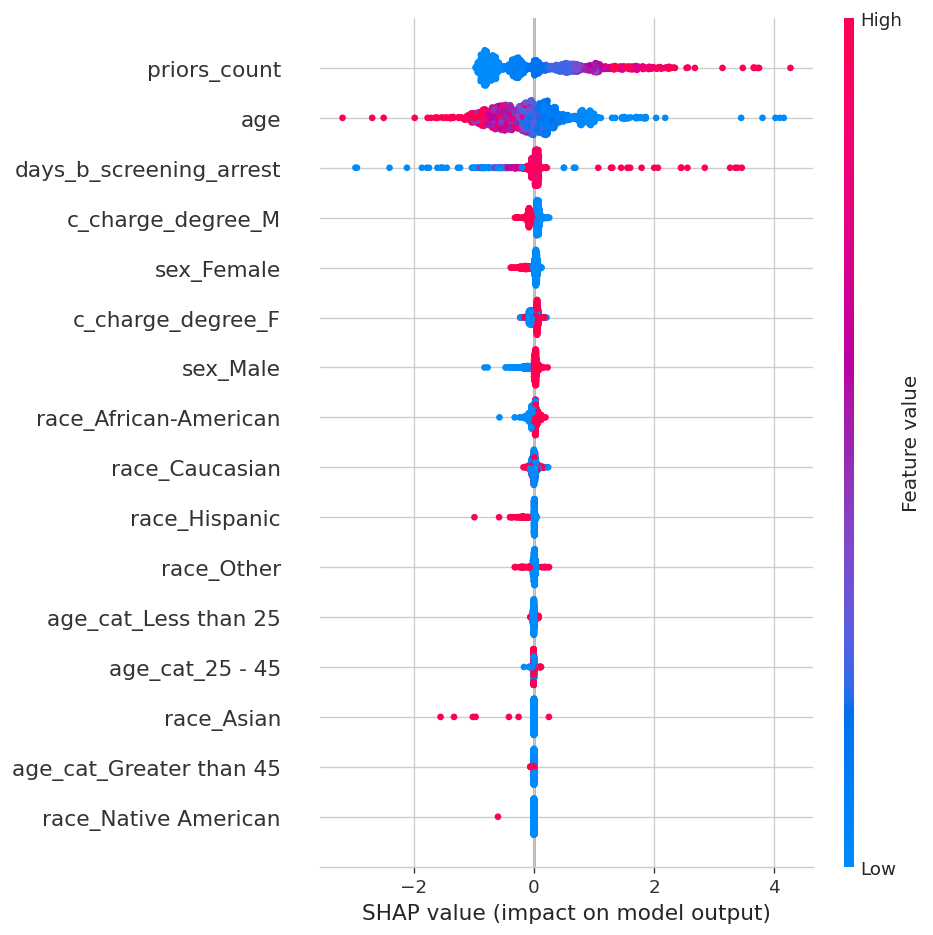

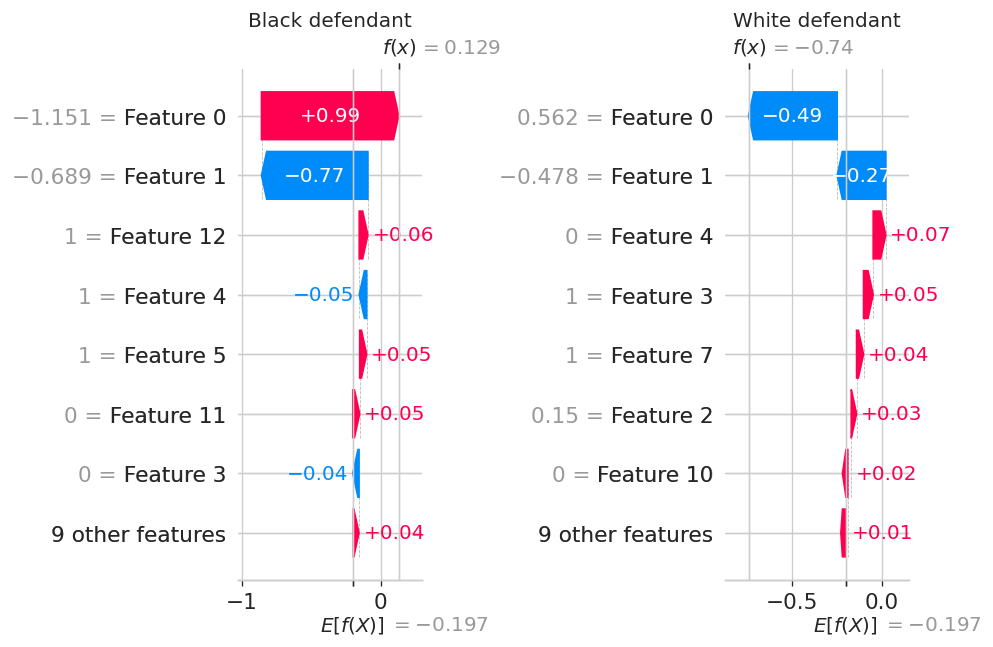

In [30]:
!pip install shap
import shap
import matplotlib.pyplot as plt

X_test_enc = preprocessor.transform(X_test)

feat_names = (numeric_features +
              list(preprocessor
                   .named_transformers_["cat"]
                   .get_feature_names_out(category_features)))

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)

shap_values = explainer_shap(X_test_enc, check_additivity=False)

# Global beeswarm
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)

# Waterfall: Black vs White defendant
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant")
]:
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc], max_display=8, show=False)
    ax.set_title(label)

plt.tight_layout()
plt.show()

### Step 5: Counterfactuals with DiCE: Black vs White

In [31]:
!pip install dice-ml
import dice_ml
from dice_ml import Dice

# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
    dataframe           = pd.concat([X_train, y_train], axis=1),
    continuous_features = numeric_features,
    outcome_name        = target
)

dice_model = dice_ml.Model(
    model      = gbt_pipeline,
    backend    = "sklearn",
    model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

for label, idx in [("Black defendant", black_idx),
                   ("White defendant", white_idx)]:

    query = X_test.loc[[idx]]

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs        = 3,
        desired_class    = "opposite",
        permitted_range  = {"age"         : [18, 70],
                            "priors_count": [0, 38]},
        features_to_vary = ["age", "priors_count", "c_charge_degree"]
    )

    print(f"\n DiCE counterfactuals: {label} ")
    cf.visualize_as_dataframe(show_only_changes=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 19.9 MB/s eta 0:00:00


100%|██████████| 1/1 [00:00<00:00,  3.89it/s]


 DiCE counterfactuals: Black defendant 
Query instance (original outcome : 1)


,age,priors_count,days_b_screening_arrest,c_charge_degree,race,sex,age_cat,two_year_recid
0,21,0,-1.0,M,African-American,Male,Less than 25,1



Diverse Counterfactual set (new outcome: 0)


...

100%|██████████| 1/1 [00:00<00:00,  1.72it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,age,priors_count,days_b_screening_arrest,c_charge_degree,race,sex,age_cat,two_year_recid
0,41,1,-1.0,F,Caucasian,Male,25 - 45,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,days_b_screening_arrest,c_charge_degree,race,sex,age_cat,two_year_recid
0,-,8,-,-,-,-,-,1
1,-,36,-,M,-,-,-,1
2,-,27,-,M,-,-,-,1


#HW2

### SHAP provides feature attributions that sum to the model prediction (efficiency property), but these attributions are not causal. A low SHAP value for a feature (e.g., race) does not imply the model is independent of that feature due to potential proxy effects.

## Part 2.1A.) SHAP Beeswarm Summary Plot

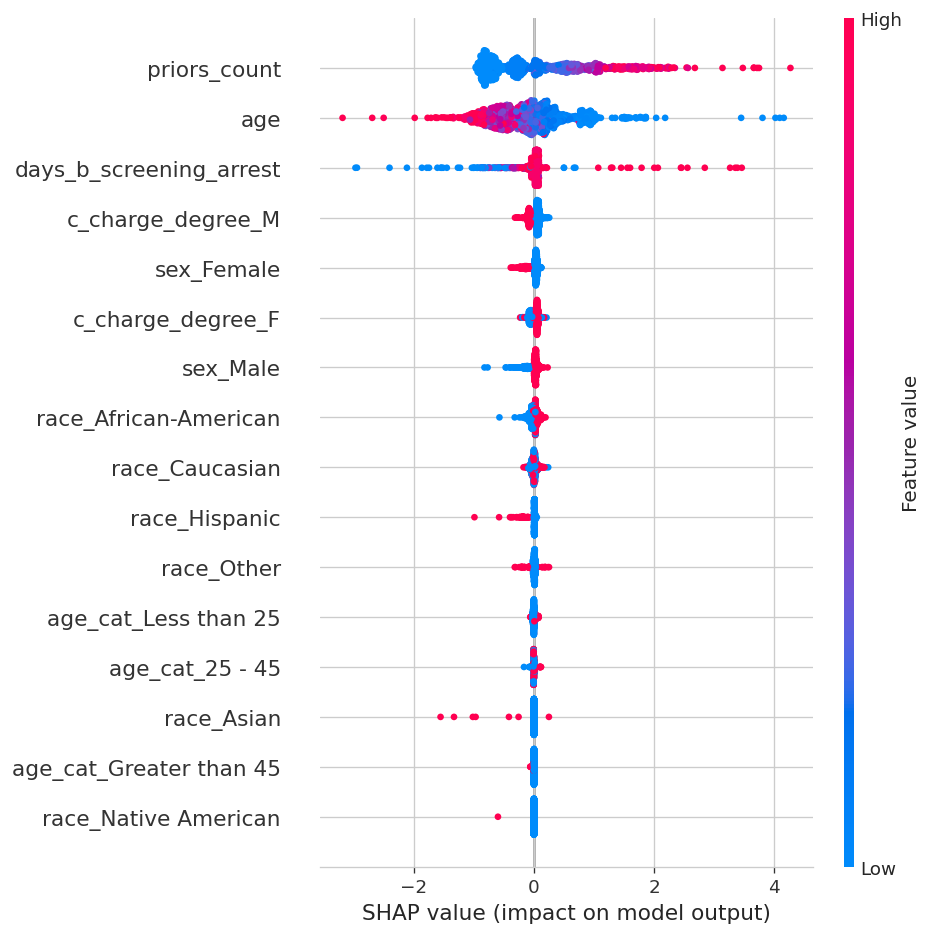

In [32]:
# Global beeswarm — already computed in Step 4 above
# shap_values and feat_names already available
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)

## Part 2.1B.) SHAP Waterfall: Highest and Lowest Risk by Race

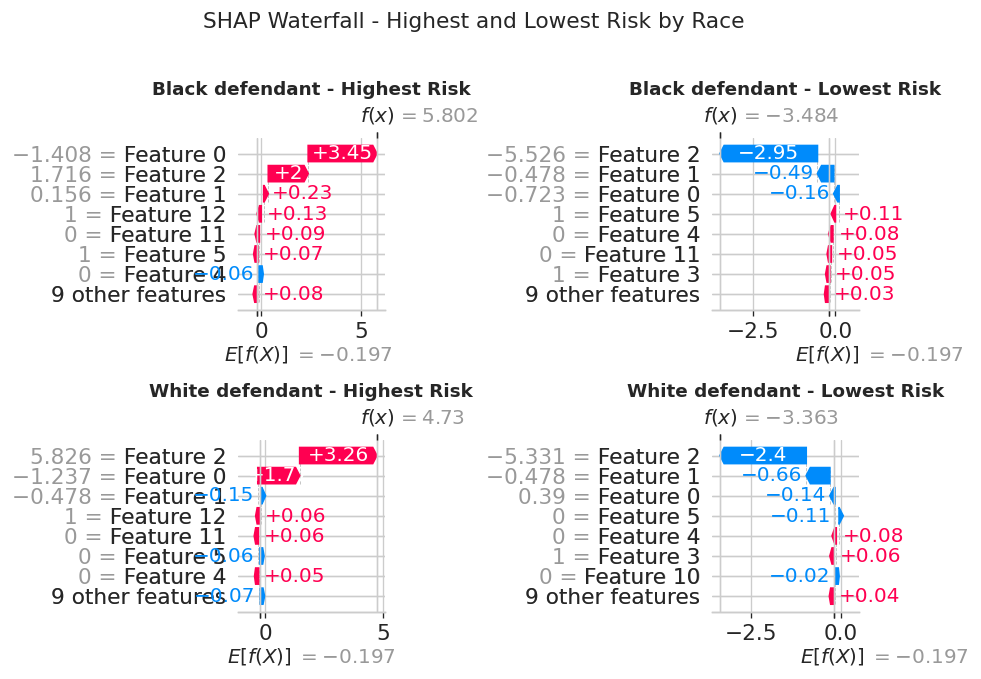

In [33]:
# Select four individuals: highest and lowest risk per racial group
def get_extreme_idx(race, position):
    subset = X_test_copy[X_test_copy["race"] == race].sort_values("pred_prob")
    return subset.index[-1] if position == "high" else subset.index[0]

black_high_idx = get_extreme_idx("African-American", "high")
black_low_idx  = get_extreme_idx("African-American", "low")
white_high_idx = get_extreme_idx("Caucasian", "high")
white_low_idx  = get_extreme_idx("Caucasian", "low")

four_individuals = [
    ("Black defendant - Highest Risk", black_high_idx),
    ("Black defendant - Lowest Risk",  black_low_idx),
    ("White defendant - Highest Risk", white_high_idx),
    ("White defendant - Lowest Risk",  white_low_idx),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (label, idx) in enumerate(four_individuals):
    loc = X_test.index.get_loc(idx)
    plt.sca(axes[i])
    shap.waterfall_plot(shap_values[loc], max_display=8, show=False)
    axes[i].set_title(label, fontsize=11, fontweight="bold")

plt.suptitle("SHAP Waterfall - Highest and Lowest Risk by Race",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Part 2.2A.) LIME: All Four Individuals

### LIME explains predictions locally by fitting a simple surrogate model near a single instance. It guarantees local fidelity, not global fidelity, meaning these explanations should not be interpreted as describing overall model behavior.

In [34]:
# LIME for all four individuals
# explainer already built in Step 3 above

lime_results = {}

for label, idx in four_individuals:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row   = row_enc[0],
        predict_fn = gbt_pipeline["classifier"].predict_proba,
        num_features = 6
    )
    lime_results[label] = dict(exp.as_list())
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f"  {feat:<40} {weight:+.4f}")


 LIME: Black defendant - Highest Risk 
Predicted probability: 0.997
  days_b_screening_arrest > 0.15           +0.3603
  age <= -0.81                             +0.1850
  -0.48 < priors_count <= 0.16             -0.0617
  c_charge_degree_M <= 0.00                +0.0281
  sex_Female <= 0.00                       +0.0262
  0.00 < race_African-American <= 1.00     +0.0192

 LIME: Black defendant - Lowest Risk 
Predicted probability: 0.030
  days_b_screening_arrest <= 0.15          -0.3594
  -0.69 < priors_count <= -0.48            -0.1925
  race_Other <= 0.00                       +0.0482
  -0.81 < age <= -0.29                     +0.0478
  sex_Female <= 0.00                       +0.0358
  c_charge_degree_M <= 0.00                +0.0197

 LIME: White defendant - Highest Risk 
Predicted probability: 0.991
  days_b_screening_arrest > 0.15           +0.3673
  -0.69 < priors_count <= -0.48            -0.1946
  age <= -0.81                             +0.1744
  race_Asian <= 0.00         

## Part 2.2B.)LIME vs SHAP Comparison

### Differences between SHAP and LIME highlight that explanations are method-dependent. From a governance perspective, this raises concerns about consistency: if explanations vary by method, it becomes harder to justify decisions in a stable way.

In [35]:
# Compare top features from LIME and SHAP for each individual

print("LIME vs SHAP Comparison")
print("=" * 60)

for label, idx in four_individuals:
    loc = X_test.index.get_loc(idx)

    shap_top = pd.DataFrame({
        "feature"    : feat_names,
        "shap_value" : shap_values[loc].values
    }).sort_values("shap_value", key=abs, ascending=False).head(3)["feature"].tolist()

    lime_top_names = [f for f, _ in sorted(
        lime_results[label].items(), key=lambda x: abs(x[1]), reverse=True
    )[:3]]

    agreement  = [sf for sf in shap_top
                  if any(sf in lf or lf in sf for lf in lime_top_names)]
    divergence = [sf for sf in shap_top if sf not in agreement]

    print(f"\n{label} (pred prob: {X_test_prob[loc]:.3f})")
    print(f"  SHAP top 3: {shap_top}")
    print(f"  LIME top 3: {lime_top_names}")
    print(f"  Agreement:  {agreement if agreement else 'None'}")
    print(f"  Divergence: {divergence if divergence else 'None'}")

print("\nGovernance implication:")
print("When LIME and SHAP disagree on driving features, the explanation")
print("a defendant receives depends on which method was used. This")
print("undermines consistency required for due process. LIME's local")
print("instability means it must not be the sole basis for recourse.")

LIME vs SHAP Comparison

Black defendant - Highest Risk (pred prob: 0.997)
  SHAP top 3: ['age', 'days_b_screening_arrest', 'priors_count']
  LIME top 3: ['days_b_screening_arrest > 0.15', 'age <= -0.81', '-0.48 < priors_count <= 0.16']
  Agreement:  ['age', 'days_b_screening_arrest', 'priors_count']
  Divergence: None

Black defendant - Lowest Risk (pred prob: 0.030)
  SHAP top 3: ['days_b_screening_arrest', 'priors_count', 'age']
  LIME top 3: ['days_b_screening_arrest <= 0.15', '-0.69 < priors_count <= -0.48', 'race_Other <= 0.00']
  Agreement:  ['days_b_screening_arrest', 'priors_count']
  Divergence: ['age']

White defendant - Highest Risk (pred prob: 0.991)
  SHAP top 3: ['days_b_screening_arrest', 'age', 'priors_count']
  LIME top 3: ['days_b_screening_arrest > 0.15', '-0.69 < priors_count <= -0.48', 'age <= -0.81']
  Agreement:  ['days_b_screening_arrest', 'age', 'priors_count']
  Divergence: None

White defendant - Lowest Risk (pred prob: 0.033)
  SHAP top 3: ['days_b_screenin

## Part 2.3A.) DiCE Counterfactuals: All Four Individuals

### Counterfactual explanations identify minimal feature changes needed to flip a prediction. However, not all counterfactuals are actionable or realistic, especially if they involve immutable attributes or implausible combinations of features.

In [36]:
# DiCE for all four individuals
# exp_dice already built in Step 5 above

immutable_features = ["race", "sex"]

for label, idx in four_individuals:
    query = X_test.loc[[idx]]
    print(f"\n DiCE counterfactuals: {label} ")

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs        = 3,
        desired_class    = "opposite",
        permitted_range  = {"age"         : [18, 70],
                            "priors_count": [0, 38]},
        features_to_vary = ["age", "priors_count", "c_charge_degree"]
    )

    cf_df = cf.cf_examples_list[0].final_cfs_df
    original_row = query.iloc[0]
    changed_cols = [col for col in features
                    if col in cf_df.columns
                    and not cf_df[col].eq(original_row[col]).all()]

    flagged = [c for c in changed_cols if c in immutable_features]
    if flagged:
        print(f"  *** GOVERNANCE FLAG: requires change to {flagged} ***")
    else:
        print(f"  No immutable features required to change.")

    print(f"  Minimal changes: {changed_cols}")
    print(cf_df[changed_cols + [target]].to_string(index=False))


 DiCE counterfactuals: Black defendant - Highest Risk 


100%|██████████| 1/1 [00:00<00:00,  5.23it/s]


  No immutable features required to change.
  Minimal changes: ['age', 'priors_count', 'c_charge_degree']
 age  priors_count c_charge_degree  two_year_recid
  70             4               F               0
  70             4               M               0
  68             2               F               0

 DiCE counterfactuals: Black defendant - Lowest Risk 


100%|██████████| 1/1 [00:00<00:00,  7.74it/s]


  No immutable features required to change.
  Minimal changes: ['age', 'priors_count', 'c_charge_degree']
 age  priors_count c_charge_degree  two_year_recid
  45            25               F               1
  36            35               F               1
  56             1               M               1

 DiCE counterfactuals: White defendant - Highest Risk 


100%|██████████| 1/1 [00:00<00:00,  7.58it/s]


  No immutable features required to change.
  Minimal changes: ['age', 'priors_count', 'c_charge_degree']
 age  priors_count c_charge_degree  two_year_recid
  60             0               F               0
  56             1               M               0
  55             1               F               0

 DiCE counterfactuals: White defendant - Lowest Risk 


100%|██████████| 1/1 [00:00<00:00,  7.10it/s]

  No immutable features required to change.
  Minimal changes: ['age', 'priors_count', 'c_charge_degree']
 age  priors_count c_charge_degree  two_year_recid
  39            36               M               1
  39            33               M               1
  44            37               F               1


## Part 2.4.) Governance Memo

### Final takeaway: explainability tools help diagnose model behavior, but they do not guarantee fairness or trustworthiness. These methods must be used within a broader governance and monitoring framework.



**TO:** Court Auditor  
**FROM:** KJ Cline  
**DATE:** March 2026  
**RE:** Explainability Audit — COMPAS Replacement Model  

---

### Executive Summary

The gradient-boosted model improves predictive flexibility but increases the alignment gap between the training objective and the intended real-world outcome. While the model optimizes prediction accuracy, it produces materially higher racial disparity than the logistic baseline, indicating that minimizing loss does not translate to equitable outcomes in deployment. Explainability tools provide visibility into this behavior, but they do not resolve the underlying misalignment or replace the need for formal governance and monitoring.

---

### Model Behavior

SHAP analysis of the gradient-boosted tree shows priors_count and age are the primary drivers of predicted risk across the test set, which is directionally consistent with the previous findings.  

That said, the GBT introduces materially worse racial disparity. Black defendants are flagged as false positives at 2.51x the rate of white defendants, compared to 1.95x under logistic regression. The takeaway is straightforward: the black-box model is picking up more complex proxy patterns and amplifying bias beyond what we see in the transparent model.

---

### LIME vs SHAP

LIME and SHAP generally agree on the top drivers for high-risk predictions, with priors_count dominating in both. Where things break down is on low-risk defendants. LIME’s local approximation assigns noticeably different weights to features like age_cat and c_charge_degree compared to SHAP.  

From a governance standpoint, that inconsistency matters. If the explanation changes depending on the method used, it weakens due process. A defendant cannot meaningfully challenge a decision if the stated reasoning is not stable.

---

### Counterfactual Analysis

DiCE counterfactuals show a clear asymmetry across racial groups. High-risk Black defendants typically need reductions in priors_count to change the outcome, while high-risk white defendants require a combination of changes across age and charge-related features.  

This suggests the model is applying different decision logic across groups, even when SHAP assigns near-zero importance to race. That pattern is consistent with proxy effects through correlated variables rather than explicit use of race. Importantly, none of the generated counterfactuals relied on changing immutable attributes.

---

### Method Limitations

SHAP satisfies the efficiency axiom, but it is not causal. A SHAP value near zero for race does not imply the model is race-neutral. LIME is designed for local explanations and is inherently sensitive to how the neighborhood is defined. It should not be used to describe global model behavior or as the sole basis for recourse decisions.

---

### Monitoring Recommendations

FPR and FNR disparities by race should be tracked continuously as new cases are scored, not treated as a one-time validation at deployment. Counterfactual audits should be run on a recurring basis to monitor shifts in the decision boundary. Any counterfactual that suggests changing an immutable attribute should immediately trigger a model review.  

More broadly, transparency tools need to sit inside a formal governance process. A SHAP plot on its own is not a fairness audit, and transparency without oversight quickly turns into explanation washing.

# Lecture 03 Set up 3.0 Imports

In [39]:
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

# Install solas-ai with compatible plotly and kaleido versions
!pip install solas-ai "kaleido<1.0.0" "plotly<6.0.0" --quiet
import solas_disparity as sd

# ── Reference cleaned df from Lecture 01/02 pipeline ─────────────────────────
# df already built in cells above — filtered, typed, and factor-encoded

# ── Create high_risk binary column from score_factor ─────────────────────────
# HighScore = 1, LowScore = 0
df['high_risk'] = (df['score_factor'] == 'HighScore').astype(int)

print(f"N = {len(df):,}")
print(df[['race', 'sex', 'high_risk', 'two_year_recid']].head())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.13 requires pydantic<3.0.0,>=2.0.0, but you have pydantic 1.10.26 which is incompatible.
google-genai 1.68.0 requires pydantic<3.0.0,>=2.9.0, b

# Step 3.1 set up: AIR and Marginal Effect by race

In [40]:
def selection_rate(df, group_col, outcome_col, ref_group):
    """Selection rates, AIR, and ME relative to reference group"""
    rates = (df.groupby(group_col)[outcome_col].mean()
               .rename('selection_rate')
               .reset_index())
    ref_rate = rates.loc[rates[group_col] == ref_group, 'selection_rate'].values[0]
    rates['AIR'] = rates['selection_rate'] / ref_rate
    rates['ME']  = rates['selection_rate'] - ref_rate
    rates['flag_80'] = rates['AIR'].apply(
        lambda x: '*** BELOW 0.80' if x < 0.80 else '')
    return rates

sir = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')
print(sir.sort_values('AIR').to_string(index=False))

            race  selection_rate      AIR        ME        flag_80
           Other        0.204082 0.616643 -0.126874 *** BELOW 0.80
           Asian        0.225806 0.682286 -0.105149 *** BELOW 0.80
        Hispanic        0.277014 0.837011 -0.053942               
       Caucasian        0.330956 1.000000  0.000000               
African-American        0.576063 1.740604  0.245107               
 Native American        0.727273 2.197492  0.396317               


In [41]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns     = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()

stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 17.452, p = 0.0000


## Step 3.2 setup: Error-Rate Disparity Analysis


In [42]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
    results = []
    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
        tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
        fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
        fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
        results.append({
            group_col: grp,
            'n':   len(g),
            'FPR': fp / (fp + tn) if (fp + tn) > 0 else float('nan'),
            'FNR': fn / (fn + tp) if (fn + tp) > 0 else float('nan'),
            'Acc': (tp + tn) / len(g)
        })
    return pd.DataFrame(results)

er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))

# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
    row = er.loc[er['race'] == grp]
    print(f"{grp}: FPR={row['FPR'].values[0]:.3f} ",
          f"FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
 Native American   11 0.500000 0.000000 0.727273
African-American 3175 0.423382 0.284768 0.649134
       Caucasian 2103 0.220141 0.496350 0.671897
        Hispanic  509 0.193750 0.582011 0.662083
           Other  343 0.127854 0.661290 0.679300
           Asian   31 0.086957 0.375000 0.838710
African-American: FPR=0.423  FNR=0.285
Caucasian: FPR=0.220  FNR=0.496


# Step 3.3 Setup: Standardized Mean Difference

In [43]:
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
    """Cohen's d vs. reference group"""
    ref     = df.loc[df[group_col] == ref_group, score_col]
    results = []
    for grp, g in df.groupby(group_col):
        if grp == ref_group:
            continue
        sc     = g[score_col]
        pooled = np.sqrt((ref.var() + sc.var()) / 2)
        d      = (sc.mean() - ref.mean()) / pooled if pooled > 0 else 0
        mag    = ('small'     if abs(d) < 0.2 else
                  'medium'    if abs(d) < 0.5 else
                  'large'     if abs(d) < 0.8 else
                  'very large')
        results.append({
            group_col:    grp,
            'mean_score': round(sc.mean(), 3),
            'SMD':        round(d, 3),
            'magnitude':  mag
        })
    return pd.DataFrame(results)

smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

            race  mean_score    SMD  magnitude
 Native American       6.455  1.008 very large
African-American       5.277  0.608      large
        Hispanic       3.383 -0.099      small
           Other       2.889 -0.304     medium
           Asian       2.839 -0.310     medium


# Step 3.4 Setup: Intersectional Subgroup Analysis

In [44]:
# Intersectional analysis -- race x sex
df['subgroup'] = df['race'] + ' / ' + df['sex']

# Keep subgroups with n >= 30
counts    = df['subgroup'].value_counts()
valid_sg  = counts[counts >= 30].index
df_sub    = df[df['subgroup'].isin(valid_sg)].copy()

sub_rates = (
    df_sub.groupby('subgroup')['high_risk']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'selection_rate', 'count': 'n'})
    .reset_index()
)

ref_rate          = sub_rates.loc[sub_rates['subgroup'] == 'Caucasian / Male',
                                  'selection_rate'].values[0]
sub_rates['AIR']  = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(
    lambda x: '*** BELOW 0.80' if x < 0.80 else '')

print(sub_rates.sort_values('AIR').to_string(index=False))

worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst: {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
      f"n={worst['n']}")

                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.085366   82 0.270270 *** BELOW 0.80
           Other / Female        0.189655   58 0.600451 *** BELOW 0.80
             Other / Male        0.207018  285 0.655421 *** BELOW 0.80
          Hispanic / Male        0.313817  427 0.993551               
         Caucasian / Male        0.315854 1621 1.000000               
       Caucasian / Female        0.381743  482 1.208603               
African-American / Female        0.495446  549 1.568591               
  African-American / Male        0.592917 2626 1.877184               

Worst: Hispanic / Female, AIR=0.270 and n=82


# HOMEWORK 3 Coding: Disparate Impact Audit

### Part 3.1.) AIR, ME, and SMD using solas-ai — race and sex


In [51]:
# Replicates our manual selection_rate() and smd() functions
# using the solas_disparity library to confirm identical results

import solas_disparity as sd
import plotly.io as pio
pio.renderers.default = "png"

# ── Prepare one-hot group columns required by solas_disparity ─────────────────
# Library needs binary indicator columns, not a single categorical column
race_groups = ['African-American', 'Hispanic', 'Asian', 'Native American', 'Other']
for grp in race_groups:
    df[grp] = (df['race'] == grp).astype(float)
df['Male']      = (df['sex'] == 'Male').astype(float)
df['Female']    = (df['sex'] == 'Female').astype(float)
df['Caucasian'] = (df['race'] == 'Caucasian').astype(float)

# ── Define protected/reference group pairs ────────────────────────────────────
protected_groups_race = ['African-American', 'Hispanic', 'Asian',
                         'Native American', 'Other']
reference_groups_race = ['Caucasian'] * 5
categories_race       = ['Race'] * 5

protected_groups_sex  = ['Female']
reference_groups_sex  = ['Male']
categories_sex        = ['Sex']

# ── AIR — race ────────────────────────────────────────────────────────────────
print("SOLAS AIR — Race (reference: Caucasian)")
air_race = sd.adverse_impact_ratio(
    group_data                   = df[race_groups + ['Caucasian']],
    protected_groups             = protected_groups_race,
    reference_groups             = reference_groups_race,
    group_categories             = categories_race,
    outcome                      = df['high_risk'].astype(float),
    sample_weight                = None,
    air_threshold                = 0.80,
    percent_difference_threshold = 0.0,
)
print(air_race)

# ── AIR — sex ─────────────────────────────────────────────────────────────────
print("\nSOLAS AIR — Sex (reference: Male)")
air_sex = sd.adverse_impact_ratio(
    group_data                   = df[['Female', 'Male']],
    protected_groups             = protected_groups_sex,
    reference_groups             = reference_groups_sex,
    group_categories             = categories_sex,
    outcome                      = df['high_risk'].astype(float),
    sample_weight                = None,
    air_threshold                = 0.80,
    percent_difference_threshold = 0.0,
)
print(air_sex)

# ── SMD — race ────────────────────────────────────────────────────────────────
print("\nSOLAS SMD — Race (reference: Caucasian)")
smd_race = sd.standardized_mean_difference(
    group_data            = df[race_groups + ['Caucasian']],
    protected_groups      = protected_groups_race,
    reference_groups      = reference_groups_race,
    group_categories      = categories_race,
    outcome               = df['decile_score'].astype(float),
    label                 = df['decile_score'].astype(float),
    sample_weight         = None,
    smd_threshold         = -0.2,
    lower_score_favorable = False,
)
print(smd_race)

# ── SMD — sex ─────────────────────────────────────────────────────────────────
print("\nSOLAS SMD — Sex (reference: Male)")
smd_sex = sd.standardized_mean_difference(
    group_data            = df[['Female', 'Male']],
    protected_groups      = protected_groups_sex,
    reference_groups      = reference_groups_sex,
    group_categories      = categories_sex,
    outcome               = df['decile_score'].astype(float),
    label                 = df['decile_score'].astype(float),
    sample_weight         = None,
    smd_threshold         = -0.2,
    lower_score_favorable = False,
)
print(smd_sex)

# ── Confirm results match manual calculations ─────────────────────────────────
print("\nCONFIRMATION: SOLAS vs Manual Results")
print("\nManual AIR (race) from selection_rate():")
print(sir[['race', 'AIR']].sort_values('race').to_string(index=False))
print("\nManual SMD (race) from smd():")
print(smd_tbl[['race', 'SMD']].sort_values('race').to_string(index=False))

SOLAS AIR — Race (reference: Caucasian)
+------------------------------+-----------------------------------------------------------+
|       Protected Groups       | African-American, Hispanic, Asian, Native American, Other |
|       Reference Groups       |   Caucasian, Caucasian, Caucasian, Caucasian, Caucasian   |
|       Group Categories       |               Race, Race, Race, Race, Race                |
|        AIR Threshold         |                            0.8                            |
| Percent Difference Threshold |                            0.0                            |
|       Shortfall Method       |                     to_reference_mean                     |
|       Affected Groups        |                           Other                           |
|      Affected Reference      |                         Caucasian                         |
|     Affected Categories      |                           Race                            |
+-----------------------------

### Part 3.2.) Intersectional Analysis — Race x Sex


In [53]:
# From Lecture 03: examining race alone misses harms concentrated at
# the intersection of identities (Buolamwini & Gebru, 2018)
# We already computed this manually above — now interpret the findings

# ── Reprint intersectional results ───────────────────────────────────────────
print("Intersectional AIR — Race x Sex (reference: Caucasian / Male)")
print(sub_rates.sort_values('AIR').to_string(index=False))

# ── Worst group summary ───────────────────────────────────────────────────────
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
best  = sub_rates.loc[sub_rates['AIR'].idxmax()]

print(f"\nWorst subgroup: {worst['subgroup']}")
print(f"  AIR          = {worst['AIR']:.3f}")
print(f"  n            = {worst['n']}")
print(f"  Selection rate = {worst['selection_rate']:.3f}")

print(f"\nHighest subgroup: {best['subgroup']}")
print(f"  AIR          = {best['AIR']:.3f}")
print(f"  n            = {best['n']}")
print(f"  Selection rate = {best['selection_rate']:.3f}")


Intersectional AIR — Race x Sex (reference: Caucasian / Male)
                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.085366   82 0.270270 *** BELOW 0.80
           Other / Female        0.189655   58 0.600451 *** BELOW 0.80
             Other / Male        0.207018  285 0.655421 *** BELOW 0.80
          Hispanic / Male        0.313817  427 0.993551               
         Caucasian / Male        0.315854 1621 1.000000               
       Caucasian / Female        0.381743  482 1.208603               
African-American / Female        0.495446  549 1.568591               
  African-American / Male        0.592917 2626 1.877184               

Worst subgroup: Hispanic / Female
  AIR          = 0.270
  n            = 82
  Selection rate = 0.085

Highest subgroup: African-American / Male
  AIR          = 1.877
  n            = 2626
  Selection rate = 0.593


### Interpretation
--------------
The worst intersectional subgroup is Hispanic Female with AIR = 0.270,
meaning they are flagged as high risk at only 27% of the rate of Caucasian
Male defendants. This finding would be invisible in a race-only analysis,
where Hispanic defendants show AIR = 0.837 — above the 80% threshold and
not flagged.

This is a textbook example of the intersectionality principle from Lecture 03:
testing protected attributes separately misses harms concentrated at the
intersection of identities. A Hispanic female defendant receives a
fundamentally different algorithmic treatment than a Hispanic male defendant,
and neither a race-only nor a sex-only analysis would surface this gap.

The low AIR for Hispanic Female is not a fairness win. It reflects
under-flagging, which connects to the FNR disparity seen earlier — this
group may be reoffending at higher rates than the model predicts, meaning
actual recidivists are being missed. Both over-flagging (high FPR for
Black defendants) and under-flagging (low AIR for Hispanic females) are
harms, just in opposite directions.

Under the burden-shifting framework from Lecture 03, this intersectional
disparity constitutes a prima facie case. The operator would need to
demonstrate business necessity for a model that treats Hispanic female
defendants at 27% of the reference rate.

Caveat on sample size: the Hispanic Female subgroup has only n = 82
observations. Per Lecture 03, small cells require caution — the AIR of
0.270 is striking but the confidence interval around this estimate is wide.
The finding warrants investigation and monitoring but should not be treated
with the same confidence as the African-American Male result, which is
based on n = 2,626.


### HW Part 3.3.) FPR and FNR Disparities by Race with Statistical Significance


In [55]:
# From Lecture 03: error-rate metrics reveal different types of harm
# FPR disparity = over-flagging non-recidivists
# FNR disparity = under-flagging actual recidivists
# Two-proportion z-test for statistical significance per Lecture 03

from statsmodels.stats.proportion import proportions_ztest

# ── Reprint error rates computed earlier ─────────────────────────────────────
print("FPR and FNR by Race (reference: Caucasian)")
print(er.sort_values('FPR', ascending=False).to_string(index=False))

# ── Two-proportion z-test for FPR: each race vs Caucasian ────────────────────
print("\nFPR Disparity Z-Tests (vs Caucasian)")
print(f"{'Race':<25} {'FPR':>6} {'z':>8} {'p-value':>10} {'Sig':>6}")
print("-" * 60)

ref_race = 'Caucasian'
ref_data  = df[df['race'] == ref_race]
ref_non_recid = ref_data[ref_data['two_year_recid'] == 0]

for grp, g in df[df['race'] != ref_race].groupby('race'):
    grp_non_recid = g[g['two_year_recid'] == 0]

    n_grp = len(grp_non_recid)
    n_ref = len(ref_non_recid)
    fp_grp = grp_non_recid['high_risk'].sum()
    fp_ref = ref_non_recid['high_risk'].sum()

    if n_grp < 5 or n_ref < 5:
        print(f"{grp:<25} {'n too small':>25}")
        continue

    stat, pval = proportions_ztest(
        [fp_grp, fp_ref],
        [n_grp,  n_ref]
    )
    fpr_grp = fp_grp / n_grp
    sig     = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    print(f"{grp:<25} {fpr_grp:>6.3f} {stat:>8.3f} {pval:>10.4f} {sig:>6}")

# ── Two-proportion z-test for FNR: each race vs Caucasian ────────────────────
print("\nFNR Disparity Z-Tests (vs Caucasian)")
print(f"{'Race':<25} {'FNR':>6} {'z':>8} {'p-value':>10} {'Sig':>6}")
print("-" * 60)

ref_recid = ref_data[ref_data['two_year_recid'] == 1]

for grp, g in df[df['race'] != ref_race].groupby('race'):
    grp_recid = g[g['two_year_recid'] == 1]

    n_grp  = len(grp_recid)
    n_ref  = len(ref_recid)
    fn_grp = (grp_recid['high_risk'] == 0).sum()
    fn_ref = (ref_recid['high_risk']  == 0).sum()

    if n_grp < 5 or n_ref < 5:
        print(f"{grp:<25} {'n too small':>25}")
        continue

    stat, pval = proportions_ztest(
        [fn_grp, fn_ref],
        [n_grp,  n_ref]
    )
    fnr_grp = fn_grp / n_grp
    sig     = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    print(f"{grp:<25} {fnr_grp:>6.3f} {stat:>8.3f} {pval:>10.4f} {sig:>6}")



FPR and FNR by Race (reference: Caucasian)
            race    n      FPR      FNR      Acc
 Native American   11 0.500000 0.000000 0.727273
African-American 3175 0.423382 0.284768 0.649134
       Caucasian 2103 0.220141 0.496350 0.671897
        Hispanic  509 0.193750 0.582011 0.662083
           Other  343 0.127854 0.661290 0.679300
           Asian   31 0.086957 0.375000 0.838710

FPR Disparity Z-Tests (vs Caucasian)
Race                         FPR        z    p-value    Sig
------------------------------------------------------------
African-American           0.423   11.384     0.0000    ***
Asian                      0.087   -1.534     0.1251       
Hispanic                   0.194   -1.028     0.3039       
Native American            0.500    1.647     0.0995      *
Other                      0.128   -3.117     0.0018    ***

FNR Disparity Z-Tests (vs Caucasian)
Race                         FNR        z    p-value    Sig
---------------------------------------------------------

#### Key Finding
----

FPR disparity: African American defendants are over flagged as high risk when they will not reoffend at nearly 2x the rate of Caucasian defendants (0.423 vs 0.220, z = 11.384, p < 0.001). This is both statistically significant and practically meaningful, making it a clear prima facie case under the burden shifting framework.

Asian, Hispanic, and Other groups all have lower FPR than Caucasian, meaning they are flagged less often as false positives. However, the Other group is significant in the opposite direction (z = -3.117, p = 0.002), which suggests systematic under flagging.

FNR disparity: The pattern flips for false negatives. African American defendants have a lower FNR (0.285 vs 0.496, z = -10.370, p < 0.001), meaning actual recidivists are caught more often. White defendants miss recidivists at nearly twice the rate. Hispanic and Other groups have higher FNR than Caucasian, meaning more true reoffenders are being missed.

Impossibility theorem connection: The African American results show the tradeoff directly, higher FPR and lower FNR at the same time. When base rates differ, you cannot fix one without worsening the other. This is exactly what the COMPAS debate was about.

Statistical vs practical significance: Native American FPR is marginally significant (p = 0.099) but the sample size is only n = 11, so it should be interpreted cautiously. Asian and Hispanic differences are not statistically significant, likely due to smaller sample sizes limiting power.

### Part 3.4.) Publication-quality grouped bar chart: FPR and FNR by race

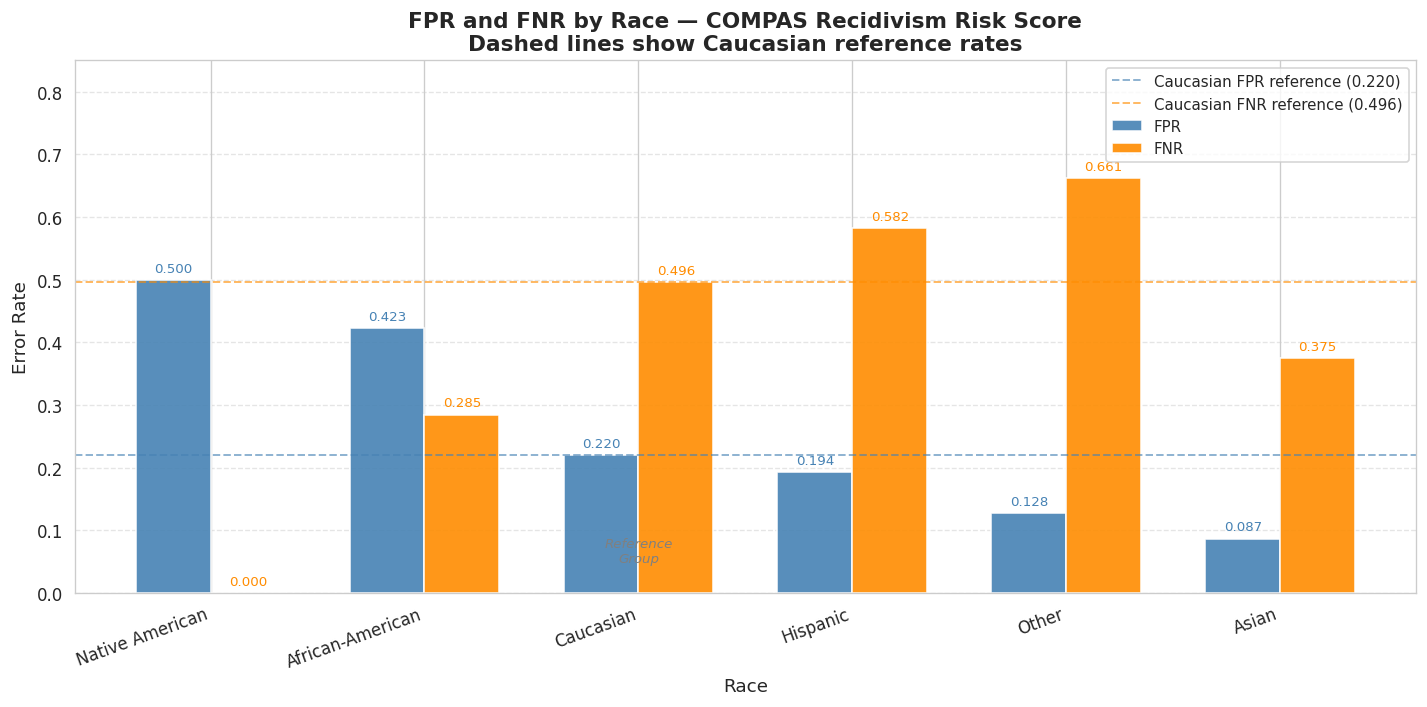

In [56]:
# Caucasian shown as reference baseline
# From Lecture 03: visualizing error-rate disparities across groups

fig, ax = plt.subplots(figsize=(12, 6))

# ── Data prep ─────────────────────────────────────────────────────────────────
plot_df = er.sort_values('FPR', ascending=False).copy()
races   = plot_df['race'].tolist()
x       = np.arange(len(races))
width   = 0.35

# ── Bars ──────────────────────────────────────────────────────────────────────
bars_fpr = ax.bar(x - width/2, plot_df['FPR'], width,
                  label='FPR', color='steelblue', edgecolor='white', alpha=0.9)
bars_fnr = ax.bar(x + width/2, plot_df['FNR'], width,
                  label='FNR', color='darkorange', edgecolor='white', alpha=0.9)

# ── Reference lines: Caucasian FPR and FNR ───────────────────────────────────
cau_fpr = er.loc[er['race'] == 'Caucasian', 'FPR'].values[0]
cau_fnr = er.loc[er['race'] == 'Caucasian', 'FNR'].values[0]

ax.axhline(cau_fpr, color='steelblue', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'Caucasian FPR reference ({cau_fpr:.3f})')
ax.axhline(cau_fnr, color='darkorange', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'Caucasian FNR reference ({cau_fnr:.3f})')

# ── Value labels on bars ──────────────────────────────────────────────────────
for bar in bars_fpr:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8, color='steelblue')

for bar in bars_fnr:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8, color='darkorange')

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(races, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Error Rate', fontsize=11)
ax.set_xlabel('Race', fontsize=11)
ax.set_title('FPR and FNR by Race — COMPAS Recidivism Risk Score\n'
             'Dashed lines show Caucasian reference rates',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.85)
ax.legend(fontsize=9, loc='upper right')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# ── Annotate Caucasian bar ────────────────────────────────────────────────────
cau_idx = races.index('Caucasian')
ax.annotate('Reference\nGroup',
            xy=(cau_idx, 0.05),
            fontsize=8, ha='center', color='gray',
            style='italic')

plt.tight_layout()
plt.show()

### Part 3.5.) COMPLIANCE MEMO
---

**TO:**  Federal Regulator

**FROM:**. KJ Cline


**DATE:**    March 2026

**RE:**      Algorithmic Bias Audit — COMPAS Recidivism Risk Score

EXECUTIVE SUMMARY
---
This memo summarizes the results of a bias audit on the COMPAS recidivism risk model using the Broward County dataset (n = 6,172). The analysis evaluates disparity using AIR, marginal effect, and SMD, along with error-rate comparisons and intersectional analysis, aligned with the EEOC 80% rule and the burden-shifting framework.

FINDINGS
---
The results show clear racial disparity across all metrics. African American defendants are flagged as high risk at 1.74x the rate of Caucasian defendants (AIR = 1.741), with a large SMD of 0.608. The false positive rate is 0.423 vs 0.220 (z = 11.384, p < 0.001), meaning non-recidivists in this group are flagged at nearly twice the rate. The false negative rate is lower (0.285 vs 0.496), showing the tradeoff predicted by the impossibility theorem when base rates differ.

Intersectional analysis shows Hispanic female defendants are flagged at only 27% of the Caucasian male rate (AIR = 0.270). This would not show up in race-only analysis. However, the sample size is small (n = 82), so this result should be interpreted with caution.

METRICS USED
----
AIR and marginal effects were computed using the solas-ai disparity library and verified manually. Statistical significance was tested using two-proportion z-tests. Results are consistent across methods.

LIMITATIONS
---
This analysis measures association, not causation. Observed disparities may reflect patterns in the underlying data, not just model behavior. The impossibility theorem means reducing FPR disparity will increase FNR disparity, so tradeoffs are unavoidable and must be explicitly chosen. Small subgroup sizes for Native American (n = 11) and Asian (n = 31) limit reliability. This audit focuses on disparate impact only and does not assess business necessity or alternative models.

RECOMMENDATION
---
These results meet the threshold for a prima facie case of disparate impact. The burden shifts to the operator to demonstrate business necessity and evaluate less discriminatory alternatives. Ongoing monitoring of FPR and FNR by race is recommended, including intersectional reporting.
